In [39]:
import matplotlib.pyplot as plt

In [40]:
func = lambda x,y: 3 + 2*x - y

In [41]:
def Cauchy_euler(func, x0, y0, b, h):
    x_vals, y_vals = [x0], [y0]
    x, y = x0, y0
    while x < b - 1e-8:
        y_new = y + h * func(x, y)
        x_new = x+h
        x_vals.append(x_new)
        y_vals.append(y_new)
        x, y = x_new, y_new
    return x_vals, y_vals

In [42]:
x, y = Cauchy_euler(func, 0, 2, 1, 0.2)

In [43]:
print(x, y)

[0, 0.2, 0.4, 0.6000000000000001, 0.8, 1.0] [2, 2.2, 2.44, 2.7119999999999997, 3.0096, 3.32768]


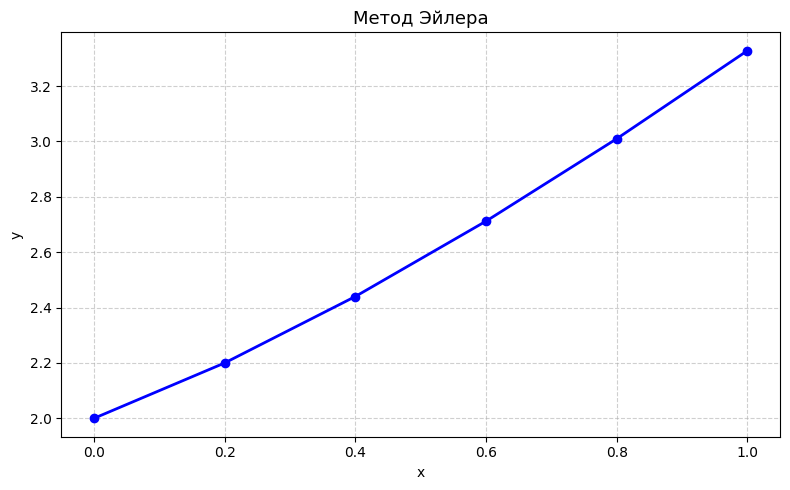

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'bo-', linewidth=2, markersize=6)
plt.title('Метод Эйлера', fontsize=13)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [45]:
def modified_euler(func, x0, y0, b, h):
    x_vals, y_vals = [x0], [y0]
    x, y = x0, y0
    while x < b - 1e-8:
        y_temp = y + h * func(x, y)
        x_new = x+h
        y_new = y + h/2*(func(x,y) + func(x_new, y_temp))
        x_vals.append(x_new)
        y_vals.append(y_new)
        x, y = x_new, y_new
    return x_vals, y_vals

In [46]:
x,y = modified_euler(func, 0, 2, 1, 0.2)

In [47]:
print(x, y)

[0, 0.2, 0.4, 0.6000000000000001, 0.8, 1.0] [2, 2.2199999999999998, 2.4724, 2.751368, 3.05212176, 3.3707398432]


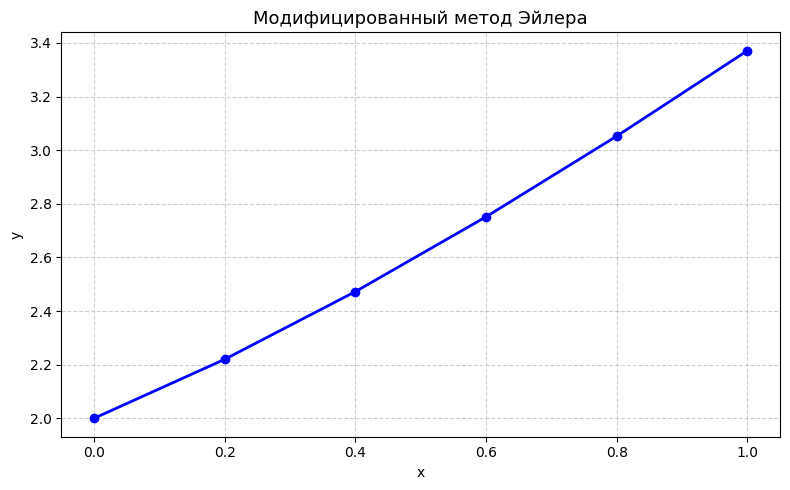

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'bo-', linewidth=2, markersize=6)
plt.title('Модифицированный метод Эйлера', fontsize=13)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [49]:
def runge_kutta(func, x0, y0, b, h):
    x_vals, y_vals = [x0], [y0]
    x, y = x0, y0
    
    while x < b - 1e-8:
        k0 = h * func(x, y)
        k1 = h * func(x + h/2, y + k0/2)
        k2 = h * func(x + h/2, y + k1/2)
        k3 = h * func(x + h, y + k2)
        
        y_new = y + (k0 + 2*k1 + 2*k2 + k3) / 6
        x_new = x + h
        
        x_vals.append(x_new)
        y_vals.append(y_new)
        x, y = x_new, y_new
        
    return x_vals, y_vals

In [50]:
x, y = runge_kutta(func, 0, 2, 1, 0.2)

In [51]:
print(x, y)

[0, 0.2, 0.4, 0.6000000000000001, 0.8, 1.0] [2, 2.2187333333333332, 2.470324271111111, 2.748816824901037, 3.0493346284406426, 3.367885238125302]


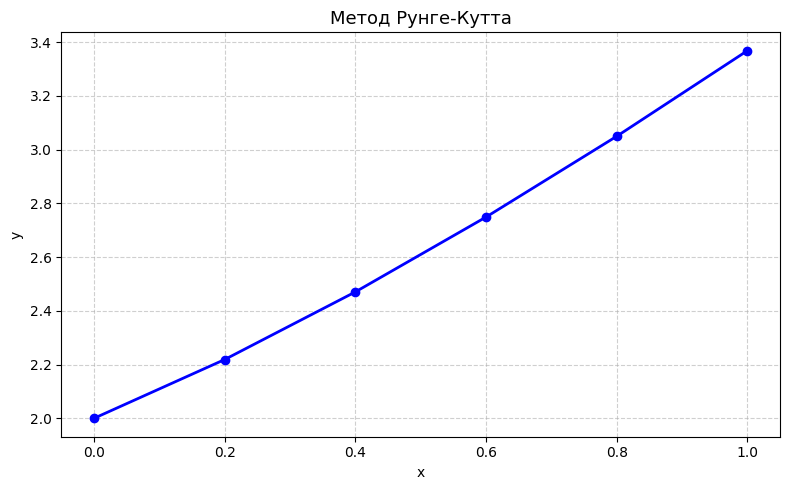

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'bo-', linewidth=2, markersize=6)
plt.title('Метод Рунге-Кутта', fontsize=13)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [53]:
def progonka(*rows):
    n = len(rows)
    a = [r[0] for r in rows]
    b = [r[1] for r in rows]
    c = [r[2] for r in rows]
    d = [r[3] for r in rows]
    
    u = [0.0] * n
    v = [0.0] * n
    solutions = [0.0] * n
    u[0] = -c[0] / b[0]
    v[0] = d[0] / b[0]
    
    for i in range(1, n - 1):
        denom = b[i] + a[i] * u[i - 1]
        
        u[i] = -c[i] / denom
        v[i] = (d[i] - a[i] * v[i - 1]) / denom

    denom_last = b[n - 1] + a[n - 1] * u[n - 2]
    v[n - 1] = (d[n - 1] - a[n - 1] * v[n - 2]) / denom_last

    solutions[n - 1] = v[n - 1]
    for i in range(n - 2, -1, -1):
        solutions[i] = u[i] * solutions[i + 1] + v[i]
        
    return solutions

In [54]:
def build_slau(p, q, f, a, b, h, left_bc, right_bc):
    n = int(round((b - a) / h)) + 1
    x = [a + i * h for i in range(n)]
    rows = []

    a1, a2, a3 = left_bc
    rows.append([0.0, a1 - a2/h, a2/h, a3])

    for i in range(1, n-1):
        xi = x[i]
        A = 1/h**2 - p(xi)/(2*h)
        B = -2/h**2 + q(xi)
        C = 1/h**2 + p(xi)/(2*h)
        D = f(xi)    
        rows.append([A, B, C, D])

    b1, b2, b3 = right_bc
    rows.append([-b2/h, b1 + b2/h, 0.0, b3])

    return x, rows

In [55]:
p = lambda x: 1/x
q = lambda x: 2
f = lambda x: x

a, b, h = 0.7, 1.0, 0.1
left_bc  = (0, 1, 0.5)
right_bc = (0, 1, 1.2)

x, rows = build_slau(p, q, f, a, b, h, left_bc, right_bc)

y = progonka(*rows)

print(x, y)

[0.7, 0.7999999999999999, 0.8999999999999999, 1.0] [-1.9195023067244434, -1.8695023067244434, -1.7826646162449244, -1.6626646162449243]


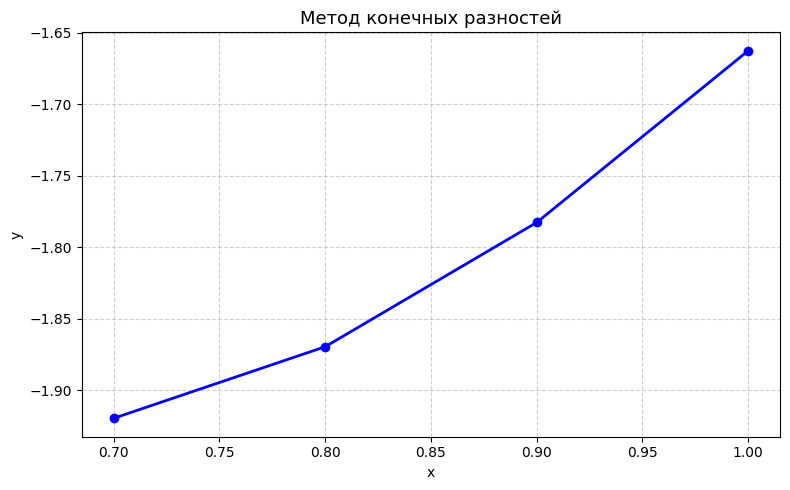

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'bo-', linewidth=2, markersize=6)
plt.title('Метод конечных разностей', fontsize=13)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()